<a href="https://www.kaggle.com/code/sonawanelalitsunil/prostate-cancer-risk-lifestyle-ml-81?scriptVersionId=252661451" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/prostate-cancer-risk-and-lifestyle-synthetic-dataset/synthetic_prostate_cancer_risk.csv


##  Title:
Prostate Cancer Risk & Lifestyle Dataset (Synthetic)

## Description:
This synthetic dataset simulates data related to prostate cancer risk factors, lifestyle habits, and demographic details. It is designed for educational and analytical purposes to explore patterns associated with prostate cancer incidence and progression. The dataset includes key features such as:

Demographics: Age, Gender, Ethnicity

Medical History: Family history of cancer, genetic mutations, PSA levels, history of previous cancers

Lifestyle Factors: Smoking status, alcohol consumption, physical activity, diet score

Clinical Indicators: BMI, presence of chronic diseases, symptom severity, diagnosis delay, treatment type

Outcome Variable: Survival years after diagnosis or cancer risk score

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/prostate-cancer-risk-and-lifestyle-synthetic-dataset/synthetic_prostate_cancer_risk.csv')

In [3]:
df.head()

,id,age,bmi,smoker,alcohol_consumption,diet_type,physical_activity_level,family_history,mental_stress_level,sleep_hours,regular_health_checkup,prostate_exam_done,risk_level
0,1,39,24.7,No,NaN,Fatty,Moderate,No,High,5.6,No,No,Medium
1,2,43,25.6,Yes,NaN,Mixed,High,No,High,6.9,Yes,No,Low
2,3,72,22.4,No,Moderate,Mixed,Moderate,No,High,7.8,Yes,No,Low
3,4,60,25.6,Yes,NaN,Fatty,Moderate,No,High,5.6,Yes,No,Medium
4,5,51,26.6,Yes,NaN,Mixed,Low,No,Medium,5.9,No,No,Medium


In [4]:
df.tail()

,id,age,bmi,smoker,alcohol_consumption,diet_type,physical_activity_level,family_history,mental_stress_level,sleep_hours,regular_health_checkup,prostate_exam_done,risk_level
995,996,73,24.5,Yes,Moderate,Healthy,Low,No,Low,5.0,No,No,Medium
996,997,42,25.5,No,NaN,Healthy,Moderate,No,High,8.1,Yes,No,Low
997,998,47,32.4,No,Moderate,Fatty,High,No,Low,7.6,No,No,Low
998,999,54,25.8,No,High,Mixed,Moderate,No,High,6.5,Yes,No,Low
999,1000,57,23.3,No,NaN,Fatty,Moderate,No,Low,7.1,Yes,Yes,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       1000 non-null   int64  
 1   age                      1000 non-null   int64  
 2   bmi                      1000 non-null   float64
 3   smoker                   1000 non-null   object 
 4   alcohol_consumption      605 non-null    object 
 5   diet_type                1000 non-null   object 
 6   physical_activity_level  1000 non-null   object 
 7   family_history           1000 non-null   object 
 8   mental_stress_level      1000 non-null   object 
 9   sleep_hours              1000 non-null   float64
 10  regular_health_checkup   1000 non-null   object 
 11  prostate_exam_done       1000 non-null   object 
 12  risk_level               1000 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 101.7+ KB


In [6]:
df.dtypes

id                           int64
age                          int64
bmi                        float64
smoker                      object
alcohol_consumption         object
diet_type                   object
physical_activity_level     object
family_history              object
mental_stress_level         object
sleep_hours                float64
regular_health_checkup      object
prostate_exam_done          object
risk_level                  object
dtype: object

In [7]:
df.describe()

,id,age,bmi,sleep_hours
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,55.159000,26.003100,6.725500
std,288.819436,14.400107,3.012387,1.320948
min,1.000000,30.000000,17.700000,4.500000
25%,250.750000,43.000000,23.900000,5.600000
50%,500.500000,55.000000,26.000000,6.700000
75%,750.250000,68.000000,28.025000,7.900000
max,1000.000000,80.000000,36.800000,9.000000


In [8]:
df.dtypes

id                           int64
age                          int64
bmi                        float64
smoker                      object
alcohol_consumption         object
diet_type                   object
physical_activity_level     object
family_history              object
mental_stress_level         object
sleep_hours                float64
regular_health_checkup      object
prostate_exam_done          object
risk_level                  object
dtype: object

In [9]:
df.isnull().sum()

id                           0
age                          0
bmi                          0
smoker                       0
alcohol_consumption        395
diet_type                    0
physical_activity_level      0
family_history               0
mental_stress_level          0
sleep_hours                  0
regular_health_checkup       0
prostate_exam_done           0
risk_level                   0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['id', 'age', 'bmi', 'smoker', 'alcohol_consumption', 'diet_type',
       'physical_activity_level', 'family_history', 'mental_stress_level',
       'sleep_hours', 'regular_health_checkup', 'prostate_exam_done',
       'risk_level'],
      dtype='object')

## Data visualizations

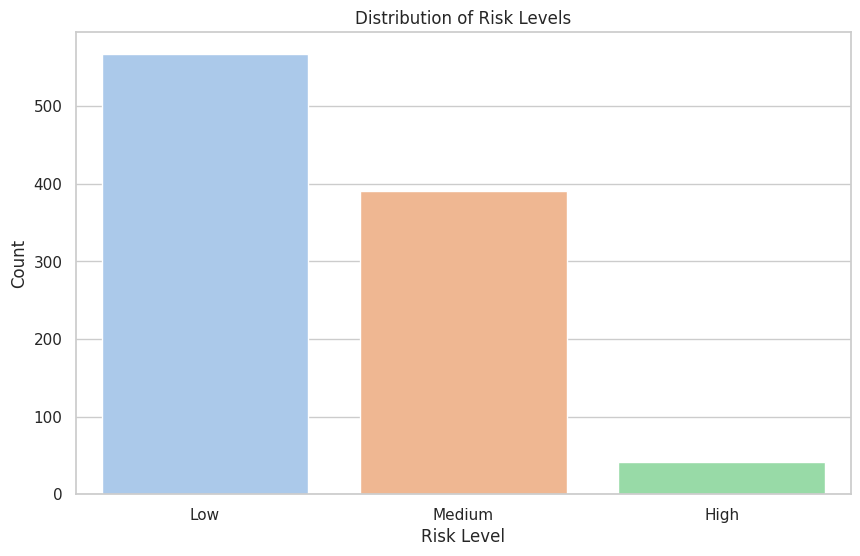

In [12]:
# Set style
sns.set(style='whitegrid', palette='pastel')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Distribution of Risk Level
plt.figure()
sns.countplot(data=df, x='risk_level', order=df['risk_level'].value_counts().index)
plt.title('Distribution of Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()

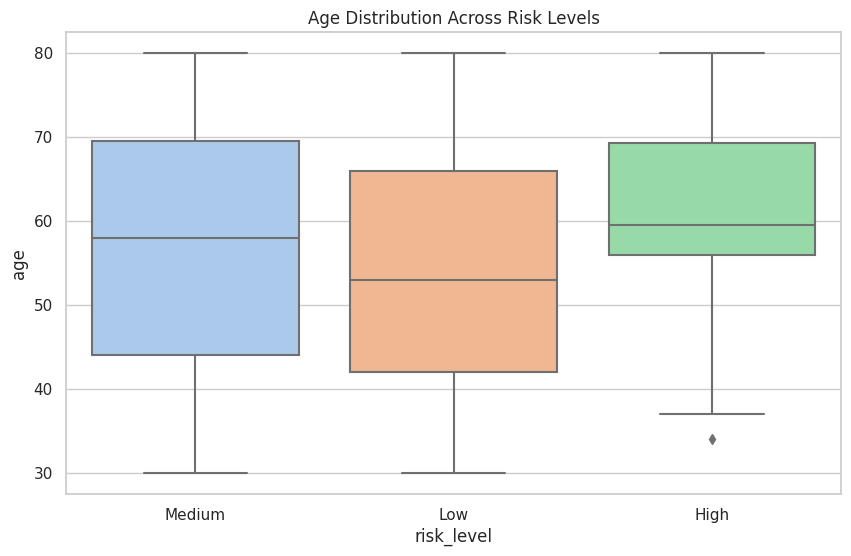

In [13]:
# 2. Age Distribution by Risk Level
plt.figure()
sns.boxplot(data=df, x='risk_level', y='age')
plt.title('Age Distribution Across Risk Levels')
plt.show()

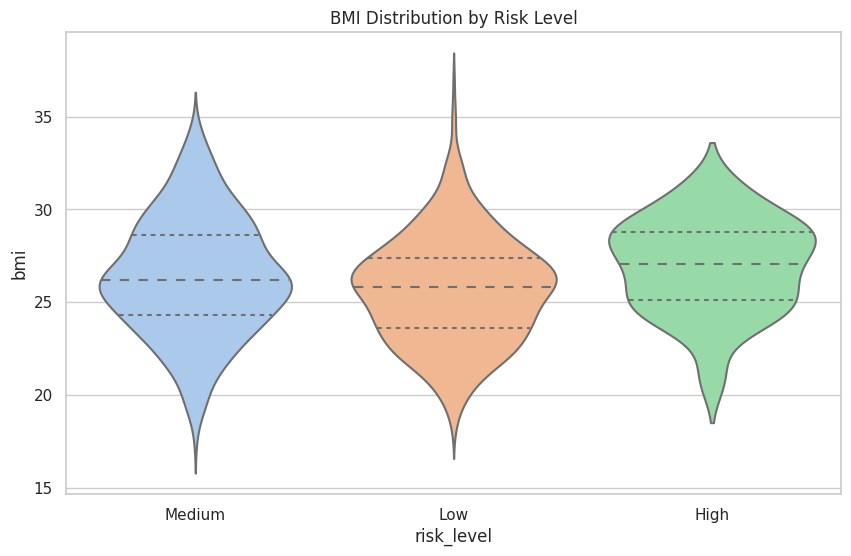

In [14]:
# 3. BMI vs Risk Level
plt.figure()
sns.violinplot(data=df, x='risk_level', y='bmi', inner='quartile')
plt.title('BMI Distribution by Risk Level')
plt.show()

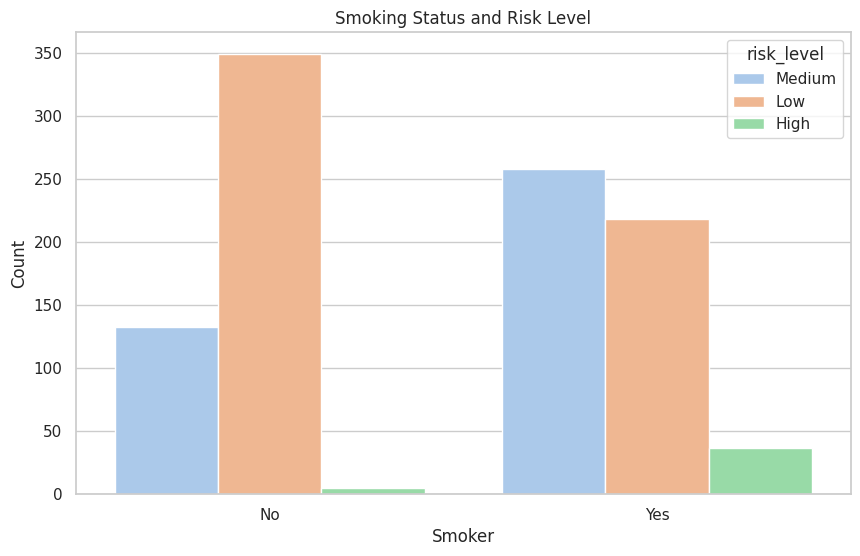

In [15]:
# 4. Smoking Status vs Risk Level
plt.figure()
sns.countplot(data=df, x='smoker', hue='risk_level')
plt.title('Smoking Status and Risk Level')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

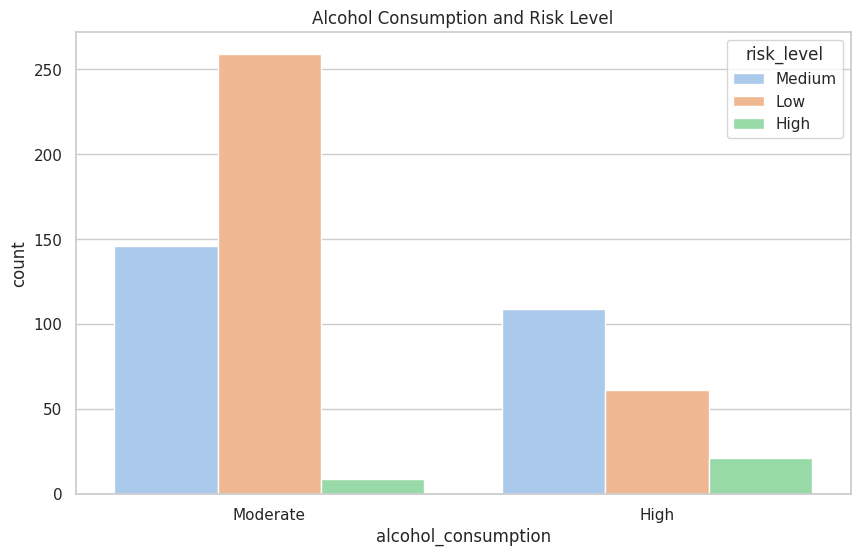

In [16]:
# 5. Alcohol Consumption vs Risk Level
plt.figure()
sns.countplot(data=df, x='alcohol_consumption', hue='risk_level')
plt.title('Alcohol Consumption and Risk Level')
plt.show()

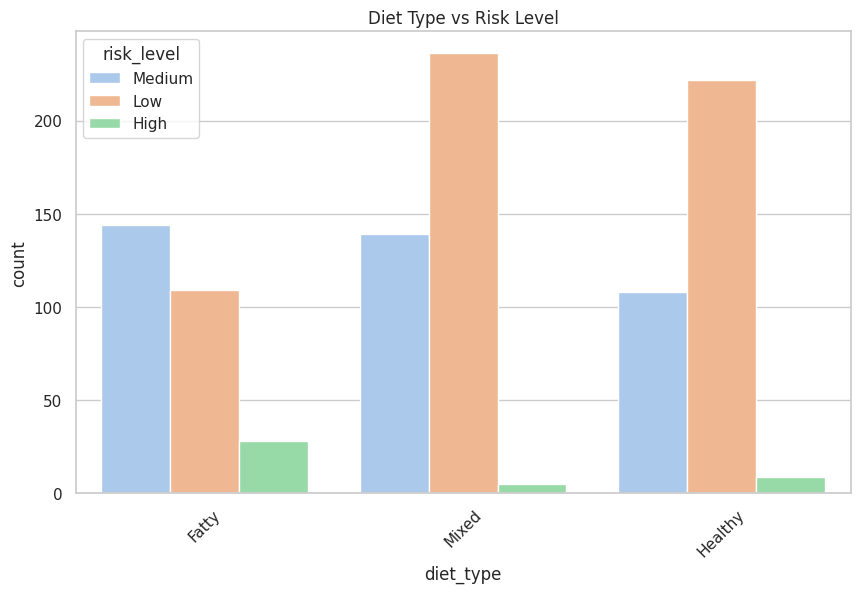

In [17]:
# 6. Diet Type vs Risk Level
plt.figure()
sns.countplot(data=df, x='diet_type', hue='risk_level')
plt.title('Diet Type vs Risk Level')
plt.xticks(rotation=45)
plt.show()


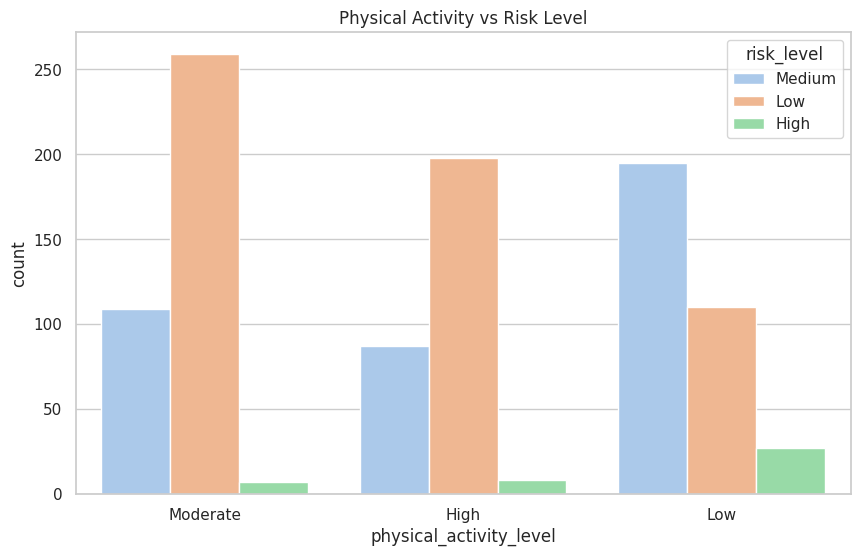

In [18]:
# 7. Physical Activity Level vs Risk Level
plt.figure()
sns.countplot(data=df, x='physical_activity_level', hue='risk_level')
plt.title('Physical Activity vs Risk Level')
plt.show()

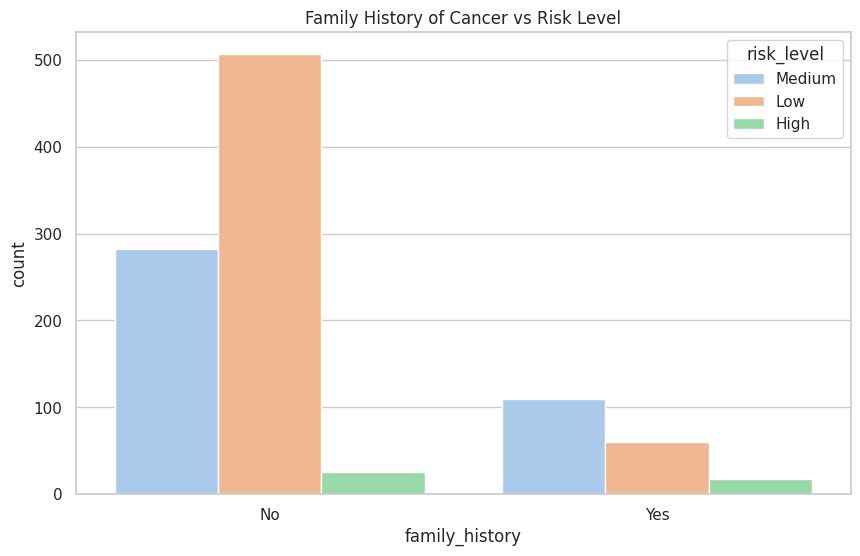

In [19]:
# 8. Family History vs Risk Level
plt.figure()
sns.countplot(data=df, x='family_history', hue='risk_level')
plt.title('Family History of Cancer vs Risk Level')
plt.show()

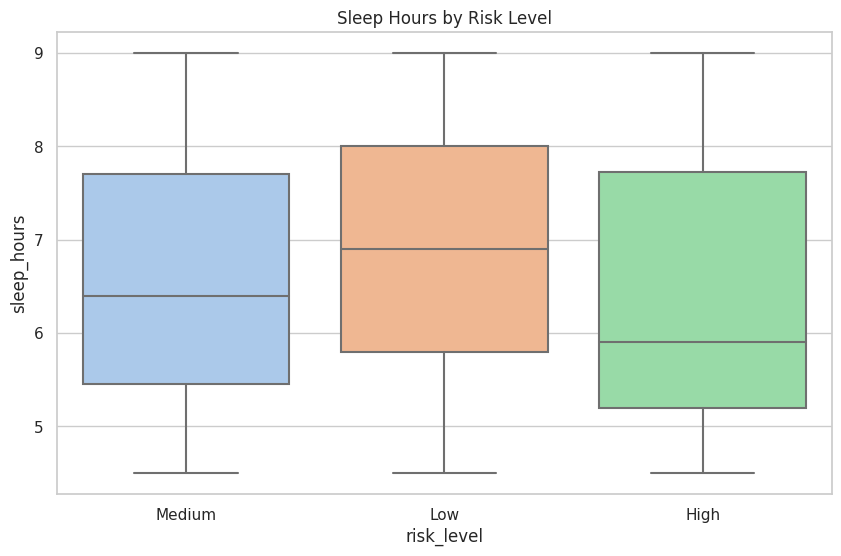

In [20]:
# 10. Sleep Hours vs Risk Level
plt.figure()
sns.boxplot(data=df, x='risk_level', y='sleep_hours')
plt.title('Sleep Hours by Risk Level')
plt.show()

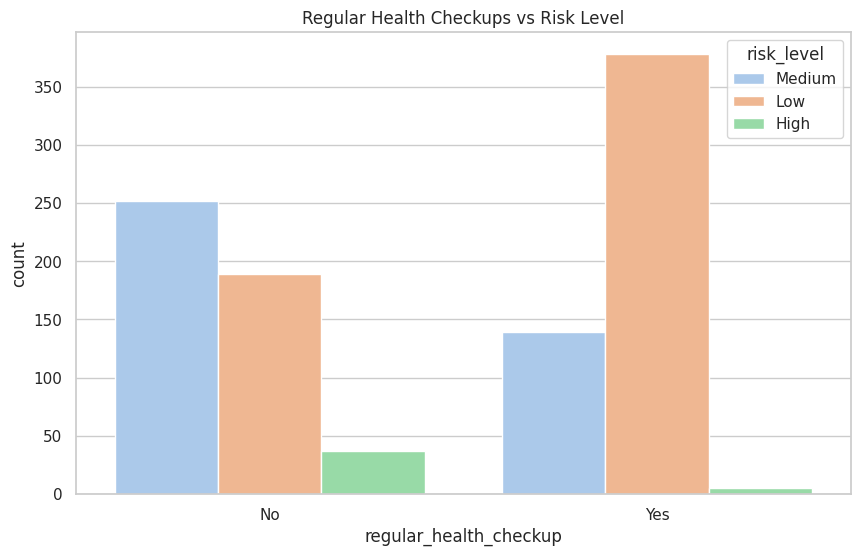

In [21]:
# 11. Regular Health Checkups vs Risk Level
plt.figure()
sns.countplot(data=df, x='regular_health_checkup', hue='risk_level')
plt.title('Regular Health Checkups vs Risk Level')
plt.show()

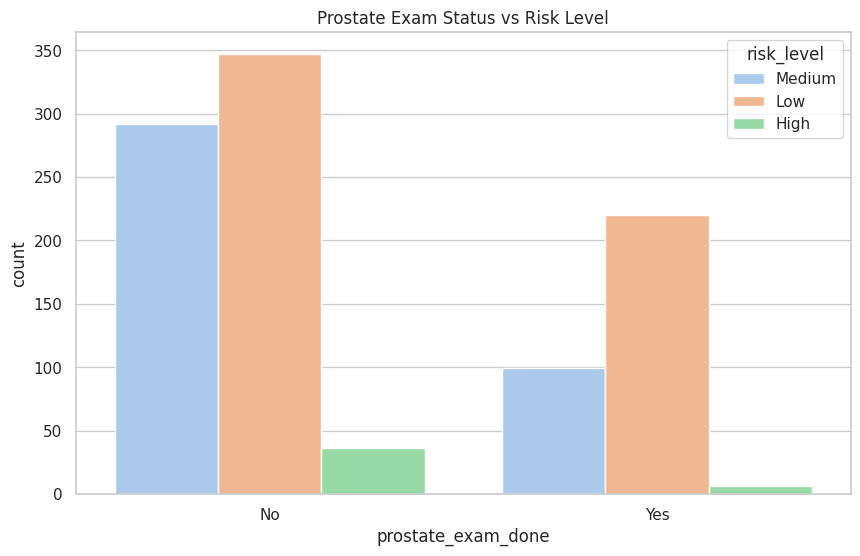

In [22]:
# 12. Prostate Exam Done vs Risk Level
plt.figure()
sns.countplot(data=df, x='prostate_exam_done', hue='risk_level')
plt.title('Prostate Exam Status vs Risk Level')
plt.show()

## Predictive modeling

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [24]:
# Drop ID column
df.drop("id", axis=1, inplace=True)

# Encode categorical features
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Features and Target
X = df.drop("risk_level", axis=1)
y = df["risk_level"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
# Models to train
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Train and evaluate
print("Model Accuracies (%):")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"{name}: {acc:.2f}%")

Model Accuracies (%):
Random Forest: 83.00%
Decision Tree: 73.50%
Logistic Regression: 76.00%
Naive Bayes: 79.50%
Support Vector Machine: 59.50%
K-Nearest Neighbors: 62.50%


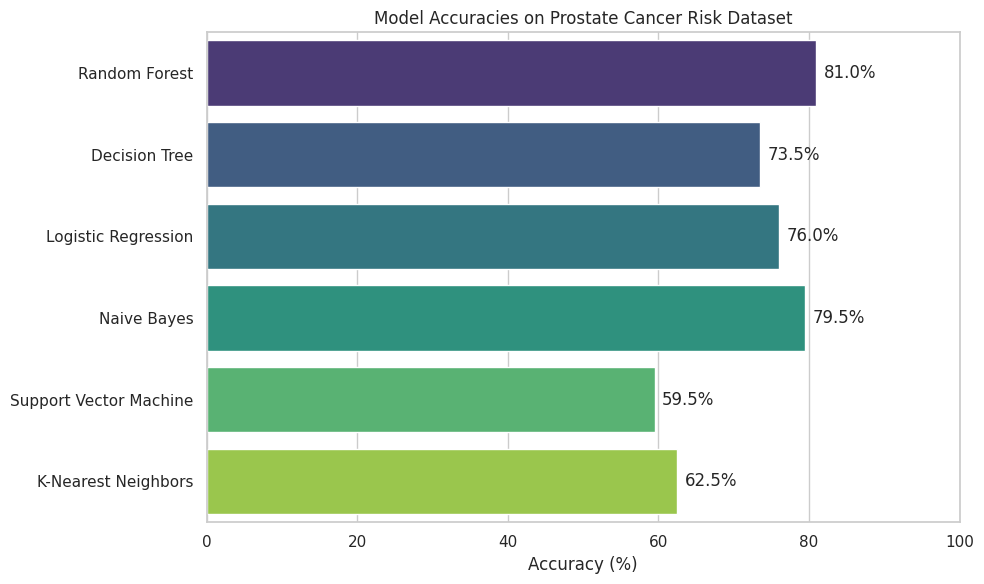

In [26]:
# Accuracy values
model_names = [
    "Random Forest",
    "Decision Tree",
    "Logistic Regression",
    "Naive Bayes",
    "Support Vector Machine",
    "K-Nearest Neighbors"
]

accuracies = [81.00, 73.50, 76.00, 79.50, 59.50, 62.50]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies, y=model_names, palette='viridis')
plt.xlabel("Accuracy (%)")
plt.title("Model Accuracies on Prostate Cancer Risk Dataset")
plt.xlim(0, 100)

# Show values on bars
for index, value in enumerate(accuracies):
    plt.text(value + 1, index, f"{value:.1f}%", va='center')

plt.tight_layout()
plt.show()

## Thank you..pls upvote!!